In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from tqdm import tqdm

# データセットのパス（例として4つのデータセットをリストとして指定）
dataset_paths = [
    "D:\Yamato\BMS\C_load1_Ans.csv",
    "D:\Yamato\BMS\C_load2_Ans.csv",
    "D:\Yamato\BMS\C_load3_Ans.csv",
    "D:\Yamato\BMS\C_load4_Ans.csv",
    "D:\Yamato\BMS\C_load5_Ans.csv",
    "D:\Yamato\BMS\C_load6_Ans.csv",
    "D:\Yamato\BMS\C_load7_Ans.csv",
    "D:\Yamato\BMS\C_load8_Ans.csv",
    "D:\Yamato\BMS\C_load9_Ans.csv",
    "D:\Yamato\BMS\C_load10_Ans.csv",
    "D:\Yamato\BMS\C_load11_Ans.csv",
    "D:\Yamato\BMS\C_load12_Ans.csv",
    "D:\Yamato\BMS\C_load13_Ans.csv",
    "D:\Yamato\BMS\C_load14_Ans.csv",
    "D:\Yamato\BMS\C_load15_Ans.csv",
    "D:\Yamato\BMS\C_load16_Ans.csv",
    "D:\Yamato\BMS\C_load17_Ans.csv",
    "D:\Yamato\BMS\C_load18_Ans.csv",
    "D:\Yamato\BMS\C_load19_Ans.csv",
    "D:\Yamato\BMS\C_load20_Ans.csv",
    "D:\Yamato\BMS\C_load21_Ans.csv",
    "D:\Yamato\BMS\C_load22_Ans.csv",
    "D:\Yamato\BMS\C_load23_Ans.csv",
    "D:\Yamato\BMS\C_load24_Ans.csv",
    "D:\Yamato\BMS\C_load25_Ans.csv",
    "D:\Yamato\BMS\C_load26_Ans.csv",
    "D:\Yamato\BMS\C_load27_Ans.csv",
    "D:\Yamato\BMS\C_load28_Ans.csv",
    "D:\Yamato\BMS\C_load29_Ans.csv",
    "D:\Yamato\BMS\C_load30_Ans.csv",
]

# データの読み込みと正規化
scaled_data = []
for path in dataset_paths:
    data = pd.read_csv(path, engine="python", encoding="utf-8")
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data.append(scaler.fit_transform(data[['Box1', 'Box2', 'Box4']]))

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
# 時系列データをLSTMの入力形式に変換する関数
def create_sequences(inputs, outputs, time_steps=1):
    X, y = [], []
    for i in range(len(inputs) - time_steps):
        X.append(inputs[i:(i + time_steps)])
        y.append(outputs[i + time_steps])
    return np.array(X), np.array(y)

In [4]:
# データセットごとに時系列データを作成し、結合する
time_steps = 20  # 過去10タイムステップを使用
X_list, y_list = [], []
for data_scaled in scaled_data:
    X_I, y = create_sequences(data_scaled[:, 0], data_scaled[:, 2], time_steps)
    X_V, _ = create_sequences(data_scaled[:, 1], data_scaled[:, 2], time_steps)
    X_combined = np.stack((X_I, X_V), axis=-1)
    X_list.append(X_combined)
    y_list.append(y)

# 全てのデータを結合
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

# PyTorchのテンソルに変換
X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)

In [5]:
import torch
import torch.nn as nn

class MyLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers):
        super(MyLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # hidden state and cell state
        h_0 = torch.zeros(self.n_layers, x.size(0), self.hidden_dim).to(x.device)
        c_0 = torch.zeros(self.n_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # LSTM forward pass
        out, (h_n, c_n) = self.lstm(x, (h_0, c_0))
        
        # Pass the output of the last time step to the fully connected layer
        out = self.fc(out[:, -1, :])
        return out

feature_size = 2
n_hidden = 64
output_dim = 1
n_layers = 1

model = MyLSTM(feature_size, n_hidden, output_dim, n_layers).to(device)
loss_function = nn.MSELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
# トレーニングデータをGPUに移動
X_train = X_train.to(device)
y_train = y_train.to(device)
model.to(device)
print(next(model.parameters()).device)

cuda:0


In [7]:
# 学習の実行
epochs = 500
losses = []
with tqdm(total=epochs) as pbar:
    for i in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_function(y_pred, y_train.view(-1, 1))
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pbar.update(1)
        pbar.set_description(f'Epoch {i}, Loss: {loss.item():.6f}')

Epoch 499, Loss: 0.008356: 100%|█████████████████████████████████████████████████████| 500/500 [28:12<00:00,  3.39s/it]


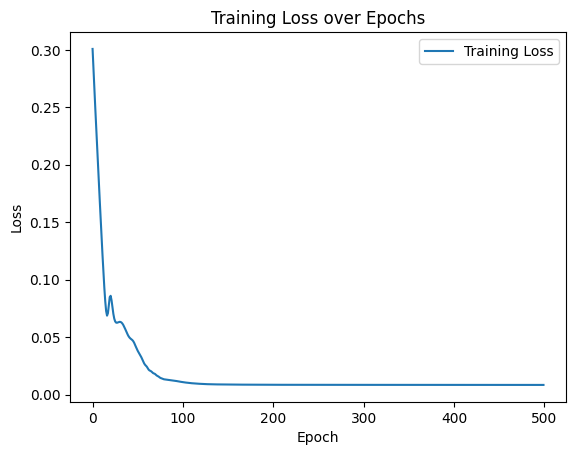

In [8]:
# Lossの推移を表示
import matplotlib.pyplot as plt

plt.plot(range(epochs), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

In [9]:
csv_data_path = "D:\Yamato\BMS\C_load15_Ans.csv"

data = pd.read_csv(csv_data_path, engine="python", encoding="utf-8")

# データが 'I', 'V', 'SOC' カラムを持っていると仮定
I = data['Box1'].values
V = data['Box2'].values
SOC = data['Box4'].values

In [10]:
# データの正規化
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['Box1', 'Box2', 'Box4']])

In [11]:
# スケールされたデータを分割
I_scaled = scaled_data[:, 0]
V_scaled = scaled_data[:, 1]
SOC_scaled = scaled_data[:, 2]

In [12]:
# 時系列データをLSTMの入力形式に変換
def create_sequences(inputs, outputs, time_steps=10):
    X, y = [], []
    for i in range(len(inputs) - time_steps):
        X.append(inputs[i:(i + time_steps)])
        y.append(outputs[i + time_steps])
    return np.array(X), np.array(y)

# 入力データの準備
time_steps = 100  # 過去10タイムステップを使用
X_I, y = create_sequences(I_scaled, SOC_scaled, time_steps)
X_V, _ = create_sequences(V_scaled, SOC_scaled, time_steps)

# 2つの入力特徴量を結合
X = np.stack((X_I, X_V), axis=-1)

In [13]:
import torch
X_test = torch.tensor(X, dtype=torch.float32)
y_test = torch.tensor(y, dtype=torch.float32)
X_test = X_test.to(device)
y_test = y_test.to(device)

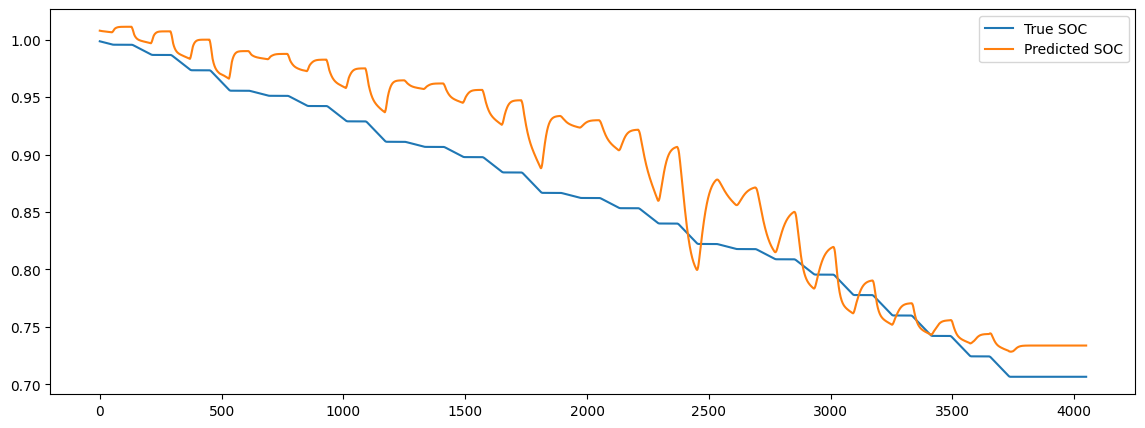

In [14]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)

# 予測結果を元のスケールに戻す
y_test_np = y_test.detach().cpu().numpy()  # GPUからCPUにデータを移動し、numpy配列に変換する
y_pred_np = y_pred.detach().cpu().numpy()
y_test_rescaled = scaler.inverse_transform(np.concatenate((np.zeros((len(y_test_np), 2)), y_test_np.reshape(-1, 1)), axis=1))[:, 2]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((np.zeros((len(y_pred_np), 2)), y_pred_np), axis=1))[:, 2]

# 結果を表示
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_rescaled, label='True SOC')
plt.plot(y_pred_rescaled, label='Predicted SOC')
plt.legend()
plt.show()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 差分を計算する
diff = y_test_rescaled - y_pred_rescaled

# データをDataFrameにまとめる
df = pd.DataFrame({
    'True SOC': y_test_rescaled,
    'Predicted SOC': y_pred_rescaled,
    'Difference': diff
})

# データフレームを表示
print(df)

# 表形式でプロット
fig, ax = plt.subplots(figsize=(14, 5))  # グラフのサイズを指定
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.round(4).values, colLabels=df.columns, cellLoc='center', loc='center', colColours=['#f5f5f5']*3)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()


      True SOC  Predicted SOC  Difference
0     0.998528       1.007758   -0.009231
1     0.998472       1.007710   -0.009238
2     0.998417       1.007665   -0.009248
3     0.998361       1.007622   -0.009261
4     0.998306       1.007582   -0.009277
...        ...            ...         ...
4045  0.706667       0.733846   -0.027179
4046  0.706667       0.733846   -0.027179
4047  0.706667       0.733846   -0.027179
4048  0.706667       0.733846   -0.027179
4049  0.706667       0.733846   -0.027179

[4050 rows x 3 columns]


ValueError: Image size of 1322x81039 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1400x500 with 1 Axes>

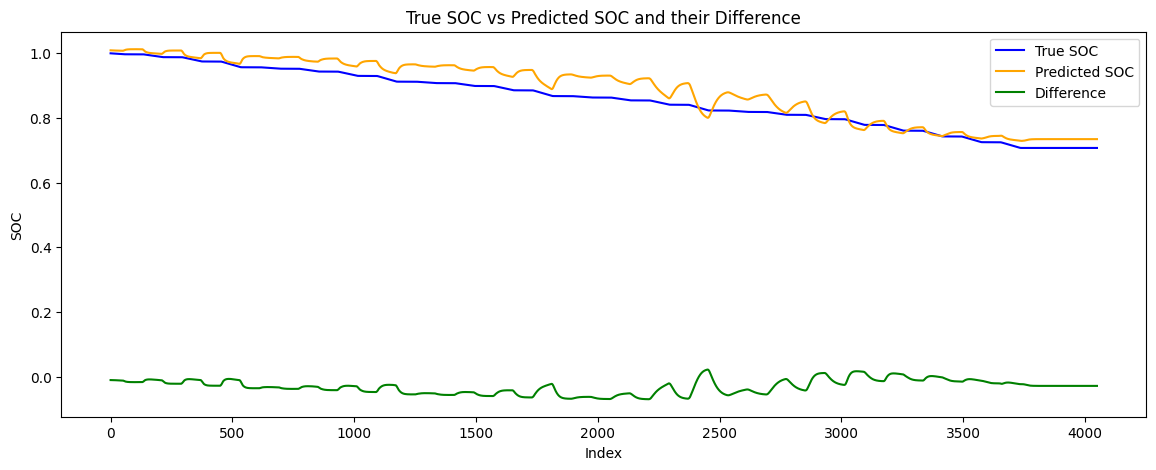

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 差分を計算する
diff = y_test_rescaled - y_pred_rescaled

# データをDataFrameにまとめる
df = pd.DataFrame({
    'True SOC': y_test_rescaled,
    'Predicted SOC': y_pred_rescaled,
    'Difference': diff
})

# 結果を表示する
plt.figure(figsize=(14, 5))
plt.plot(y_test_rescaled, label='True SOC', color='blue')
plt.plot(y_pred_rescaled, label='Predicted SOC', color='orange')
plt.plot(diff, label='Difference', color='green')
plt.legend()
plt.xlabel('Index')
plt.ylabel('SOC')
plt.title('True SOC vs Predicted SOC and their Difference')
plt.show()

